# Drawing the stages of an alignment

This notebook is an authoring tool, not a chapter of the book. It generates the
figures that illustrate how a dynamic programming matrix is filled in, one cell
at a time, straight from the two sequences and the scoring function.

Earlier these figures were produced by emitting TikZ code and compiling it with
LaTeX (see `nw_code_latex.ipynb`). Here everything is plain **SVG**, written by
[`alignviz.py`](alignviz.py), so a figure can be produced, looked at and changed
without leaving the notebook.

In [1]:
from alignviz import Alignment, Scoring, Style, player

## Example 1: the short sequences of the Needleman-Wunsch chapter

We align `GAC` and `ACG` with the scoring function used in the chapter,

$$d(x,y)= \begin{cases}1 & \textrm{if } x=y\\ -1 & \textrm{otherwise}\end{cases}$$

Building an `Alignment` runs the algorithm; nothing is drawn yet.

In [2]:
aln = Alignment("GAC", "ACG", match=1, mismatch=-1, gap=-1)
aln

Alignment('GAC', 'ACG', mode='global', score=0)

### Initialisation

`upto` says how many cells of the matrix have been filled in, counting in the
order the algorithm fills them. The first `aln.n_init` cells are the borders,
which are all set by the initialisation, $S_{i,0}=d(x,-)\cdot i$ and
$S_{0,j}=d(-,y)\cdot j$.

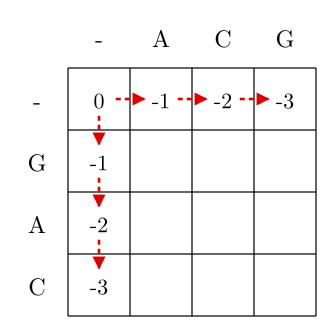

In [3]:
aln.figure(upto=aln.n_init)

### One turn of the recursion

Every interior cell is then the maximum of three candidates,

$$S_{i,j}=\max\begin{cases}S_{i-1,j-1} & + d(a_i,b_j)\\ S_{i-1,j} & + d(a_i,-)\\ S_{i,j-1} & + d(-,b_j)\end{cases}$$

`current` marks the cell being computed and `sources=True` shades the three
cells it reads from. The arithmetic behind the cell is kept in `aln.steps`, and
`expression()` formats it exactly the way the captions in the book do.

max(0+-1,-1+-1,-1+-1)=-1


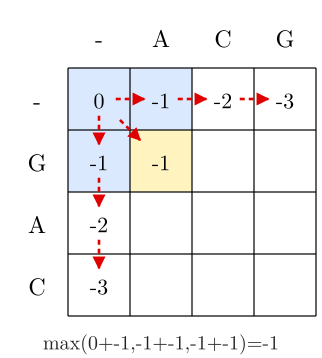

In [4]:
step = aln.steps[(1, 1)]
print(step.expression())

aln.figure(upto=aln.n_init + 1, current=(1, 1), sources=True, caption=step.expression())

### All the stages at once

`frames()` returns the whole story: the initialised borders, then one figure per
cell in the order they are filled in, then the traceback. `player()` wraps them
in a small step-through widget. It is self contained &mdash; no kernel and no
javascript library &mdash; so it survives being exported to html.

In [5]:
frames = aln.frames()
print(len(frames), "frames")

player(frames)

11 frames


The captions are the recursions themselves, so they can be reused as figure
captions in the text:

In [6]:
for k, cell in enumerate(aln.fill_cells, start=1):
    print(f"nw_short_{k + 1}: {aln.steps[cell].expression()}")

nw_short_2: max(0+-1,-1+-1,-1+-1)=-1
nw_short_3: max(-1+-1,-2+-1,-1+-1)=-2
nw_short_4: max(-2+1,-3+-1,-2+-1)=-1
nw_short_5: max(-1+1,-1+-1,-2+-1)=0
nw_short_6: max(-1+-1,-2+-1,0+-1)=-1
nw_short_7: max(-2+-1,-1+-1,-1+-1)=-2
nw_short_8: max(-2+-1,0+-1,-3+-1)=-1
nw_short_9: max(0+1,-1+-1,-1+-1)=1
nw_short_10: max(-1+-1,-2+-1,1+-1)=0


### Traceback

`traceback()` follows the pointers back from the cell the alignment ends in, and
`aligned()` turns that path into the two aligned strings. Where several moves
are equally good the diagonal is preferred, which is the convention used in the
chapter.

GAC-
-ACG
score: 0.0


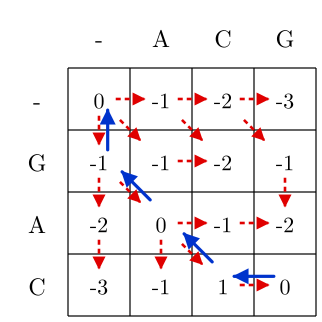

In [7]:
path = aln.traceback()
a, b = aln.aligned(path)
print(a)
print(b)
print("score:", aln.alignment_score(path))

aln.figure(path=path)

### Writing the figures to disk

`save()` takes any figure to an `.svg` file. `save_frames()` does the whole
series at once; the pattern gets the frame number substituted into it, which
reproduces the numbering `nw_short_1 ... nw_short_11` used by the chapter.

`.png` and `.pdf` also work if [cairosvg](https://cairosvg.org) is installed,
but the book renders `.svg` directly, so there is rarely a reason to.

In [8]:
# aln.save_frames("img/nw_short_{}.svg")
# aln.figure(path=path).save("img/nw_short_bt.svg")

## Example 2: longer sequences

The second example of the chapter, $a=$TGCATTA and $b=$GCATTAC, with

$$d(x,y)= \begin{cases}3 & \textrm{if } x=y\\ -2 & \textrm{if } x=\textrm{- or } y=\textrm{-}\\ -1 & \textrm{otherwise}\end{cases}$$

which is the default scoring, so it need not be spelled out.

TGCATTA-
-GCATTAC


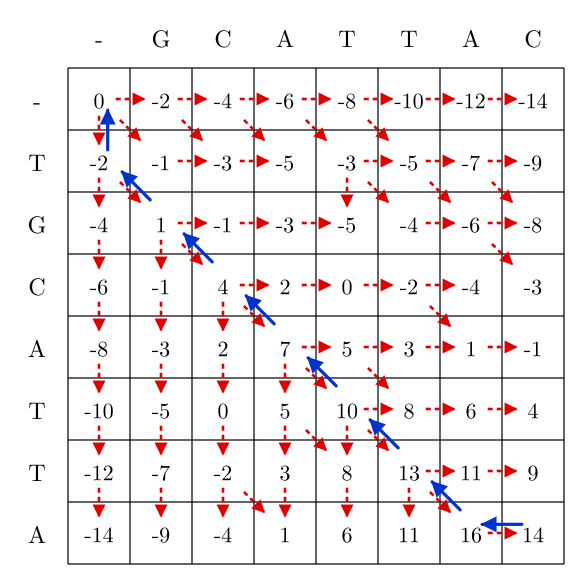

In [9]:
long = Alignment("TGCATTA", "GCATTAC")
print("\n".join(long.aligned()))

long.figure(path=long.traceback())

Note the cells with two incoming arrows: there the recursion has more than one
optimal predecessor, so more than one optimal alignment exists.

## The two exercises of the chapter

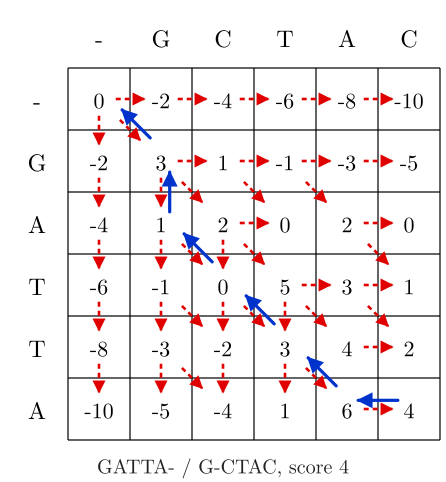

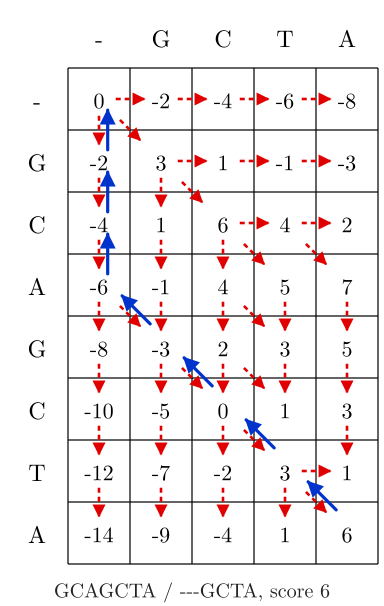

In [10]:
for name, seqA, seqB in [("nw_exe1", "GATTA", "GCTAC"),
                         ("nw_exe2", "GCAGCTA", "GCTA")]:
    ex = Alignment(seqA, seqB)
    display(ex.figure(path=ex.traceback(),
                      caption=" / ".join(ex.aligned()) + f", score {ex.score:g}"))
    # ex.figure(path=ex.traceback()).save(f"img/{name}.svg")

## Local and semi-global alignments

The same machinery draws the other two variants. `mode="local"` initiates the
borders with zeros and lets the recursion fall back on zero, and the traceback
starts from the largest cell anywhere in the matrix. `mode="semi"` initiates
with zeros but keeps the global recursion, and starts the traceback from the
largest cell of the last row or column.

local: AC / AC score 2.0


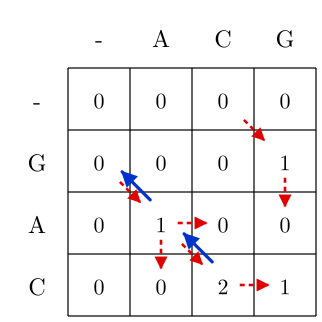

In [11]:
sw = Alignment("GAC", "ACG", match=1, mismatch=-1, gap=-1, mode="local")
print("local:", " / ".join(sw.aligned()), "score", sw.score)

sw.figure(path=sw.traceback())

semi-global: CGCTATCC / CGCTATTT score 16.0


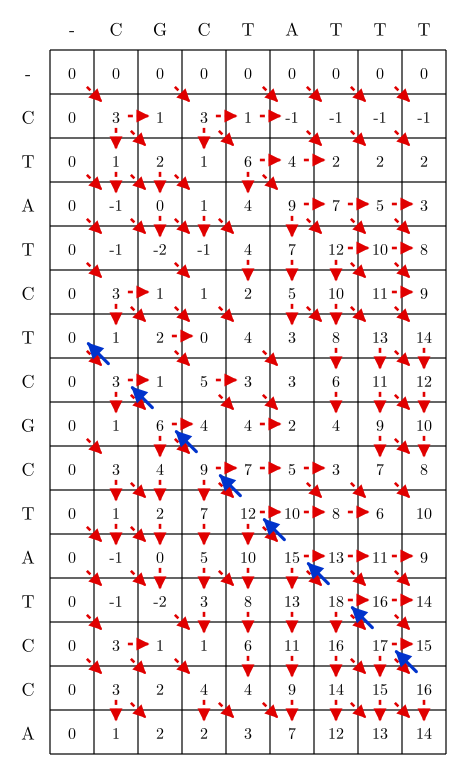

In [12]:
sg = Alignment("CTATCTCGCTATCCA", "CGCTATTT", mode="semi")
print("semi-global:", " / ".join(sg.aligned()), "score", sg.score)

sg.figure(path=sg.traceback(), style=Style(cell=44, value_size=16, letter_size=18))

Stepping through a local alignment shows nicely how the zeros keep the matrix
from ever going negative:

In [13]:
player(sw.frames(), delay=500)

## Changing how it looks

Everything about the drawing lives in a `Style`, and the scoring in a `Scoring`.
Both are plain dataclasses, so a single field can be overridden and the rest
left alone.

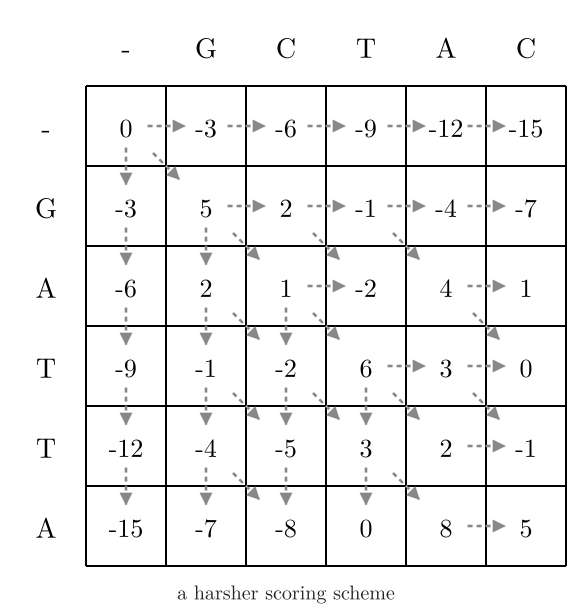

In [14]:
blueprint = Style(cell=80, value_size=26, letter_size=28,
                  trace_color="#888888", path_color="#c2185b",
                  current_fill="#f3e5f5", grid_width=2.0)

Alignment("GATTA", "GCTAC", scoring=Scoring(match=5, mismatch=-4, gap=-3)).figure(
    path=None, style=blueprint, caption="a harsher scoring scheme")

## As an app

The same module drives a small [Streamlit](https://streamlit.io) app, in which
the sequences, the scoring and the alignment mode are widgets and the matrix
redraws as you type:

```
streamlit run alignviz_app.py
```